### Import Modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re

### GPU/Power Log

In [3]:
log_path = "gpu_profile_dmon_128.log"

# 로그 파일에서 데이터 파싱
gpu_data = []
with open(log_path, "r") as file:
    lines = file.readlines()

current_time_index = 0
for line in lines:
    # 데이터 행은 공백으로 시작하는 숫자들로 이루어짐
    if re.match(r"\s+\d+", line):
        parts = line.strip().split()
        if len(parts) >= 3:
            gpu_id = int(parts[0])
            power = int(parts[1])
            util = int(parts[4])
            gpu_data.append({
                "time": current_time_index,
                "gpu_id": gpu_id,
                "power": power,
                "util": util,
            })
        current_time_index += 1 if gpu_id == 7 else 0  # 4~7 모두 본 후 시간 증가

# DataFrame 생성
df = pd.DataFrame(gpu_data)

FileNotFoundError: [Errno 2] No such file or directory: 'gpu_profile_dmon_128.log'

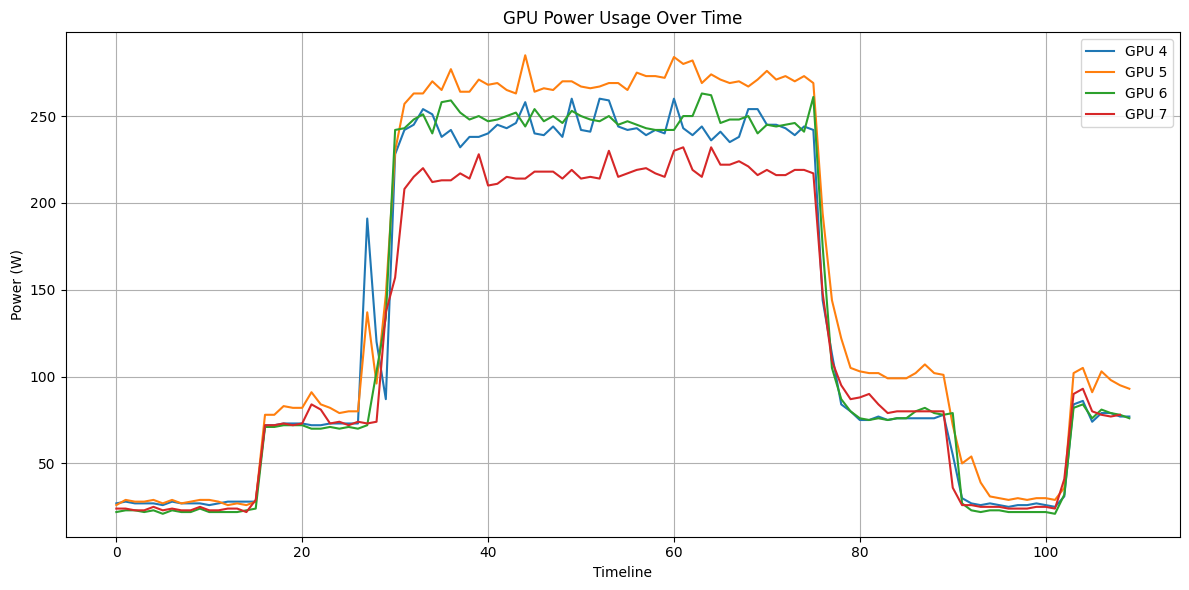

In [3]:
plt.figure(figsize=(12, 6))
for gpu_id in sorted(df["gpu_id"].unique()):
    gpu_df = df[df["gpu_id"] == gpu_id]
    plt.plot(gpu_df["time"], gpu_df["power"], label=f"GPU {gpu_id}")

plt.xlabel("Timeline")
plt.ylabel("Power (W)")
plt.title("GPU Power Usage Over Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

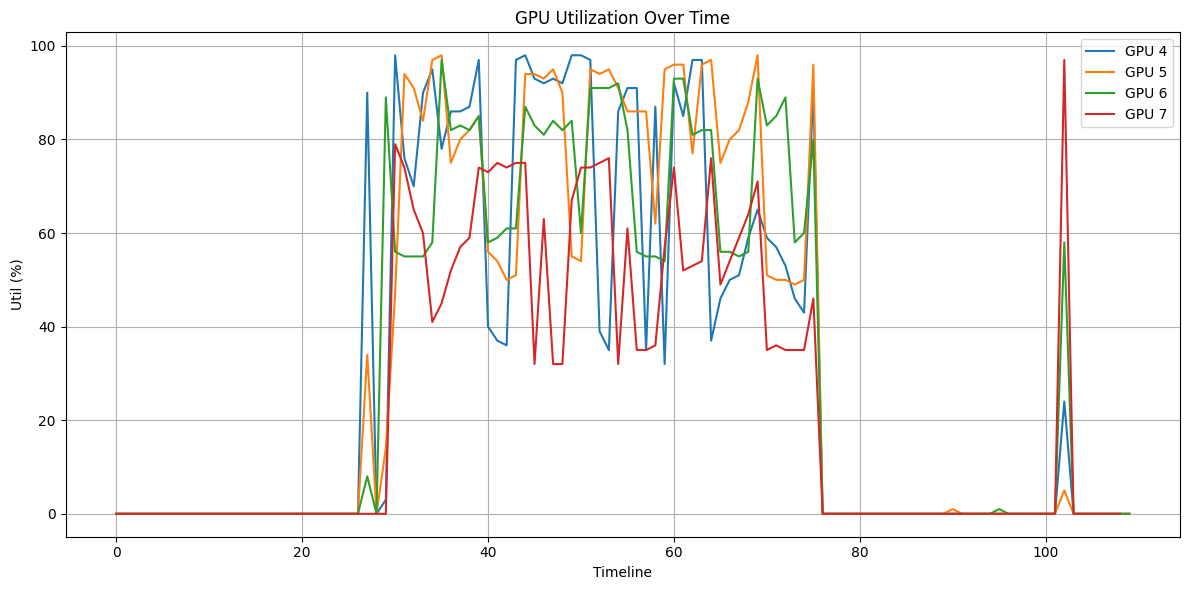

In [4]:
plt.figure(figsize=(12, 6))
for gpu_id in sorted(df["gpu_id"].unique()):
    gpu_df = df[df["gpu_id"] == gpu_id]
    plt.plot(gpu_df["time"], gpu_df["util"], label=f"GPU {gpu_id}")

plt.xlabel("Timeline")
plt.ylabel("Util (%)")
plt.title("GPU Utilization Over Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### NVTX push/pop B128 Create CSV

In [5]:
import pandas as pd
import re

# Load NVTX-parsed TSV
type = "_default" # _even or _optim or _default
file_path = "../nsys_logs/dpipe-profile-b8-gpu3_nvtx.tsv"

df = pd.read_csv(file_path, sep='\t')

# Step 1: Filter relevant rows
df = df[df["Name"].astype(str).str.startswith(":Task=")].copy()

def time_to_ms(value: str) -> float:
    value = value.strip()
    if value.endswith('ms'):
        return float(value.replace('ms', '').strip())
    elif value.endswith('us') or value.endswith('μs'):
        return float(value.replace('us', '').replace('μs', '').strip()) / 1000
    elif value.endswith('ns'):
        return float(value.replace('ns', '').strip()) / 1_000_000
    elif value.endswith('s'):
        return float(value.replace('s', '').strip()) * 1000
    else:
        return pd.to_numeric(value, errors='coerce')  # fallback

# Convert Start, End, Duration to ms
for col in ["Start", "End", "Duration"]:
    df[col] = df[col].apply(time_to_ms)

# Step 3: Regex match
pattern = re.compile(
    r":Task=(?P<task>[\w_]+)\s+\|\s+"
    r"Batch=(?P<batch>\d+)\s+UBatch=(?P<ubatch>\d+)\s+\|\s+"
    r"Partition=(?P<partition>\d+)\s+Target=(?P<target>True|False|0|1)\s+\|\s+"
    r"GPU=(?P<gpu>None|\d+)"
)

parsed_data = df["Name"].apply(lambda x: pattern.search(x) if isinstance(x, str) else None)
df_parsed = pd.DataFrame([m.groupdict() if m else {} for m in parsed_data], index=df.index)

# Step 4: Convert columns to appropriate types
for col in ['batch', 'ubatch', 'partition']:
    df_parsed[col] = pd.to_numeric(df_parsed[col], errors='coerce')
df_parsed['target'] = df_parsed['target'].map({'True': True, 'False': False, '0': False, '1': True})
df_parsed['gpu'] = df_parsed['gpu'].replace('None', -1).astype(int)

# Step 5: Filter valid GPU rows using aligned indices
valid_indices = df_parsed[df_parsed['gpu'] != -1].index
df_subset = df.loc[valid_indices, ["Start", "End", "Duration"]].reset_index(drop=True)
df_parsed_filtered = df_parsed.loc[valid_indices].reset_index(drop=True)

# Step 6: Merge and export
df_combined = pd.concat([df_subset, df_parsed_filtered], axis=1)
df_combined.to_csv(f"gpu_task_summary_i100_batch6_10_b512{type}_time.csv", index=False)

df_combined.head()


KeyError: 'Name'

In [20]:
df_merged = pd.read_csv(f"gpu_task_summary_i100_batch6_10_b512{type}_time.csv")
# df_mem = pd.read_csv(f"gpu_task_summary_i100_batch6_10_b128{type}_mem.csv")
# df_time['target'] = df_time['target'].astype(bool)
# df_mem['target'] = df_mem['target'].astype(bool)

# merge_keys = ["task", "batch", "ubatch", "partition", "target", "gpu"]
# df_merged = pd.merge(df_time, df_mem, on=merge_keys, how="left")

# merged_path = f"gpu_task_summary_i100_batch6_10_b128{type}_combined.csv"
# df_merged.to_csv(merged_path, index=False)
# 
df_merged.head()

,Start,End,Duration,task,batch,ubatch,partition,target,gpu
0,30679.0,30681.6,2.574,copy_model,6,0,0,True,0
1,30784.3,30804.9,20.632,copy_batch,6,0,0,True,0
2,30829.7,31121.0,291.240,compute_forward,6,0,0,True,0
3,30855.6,31122.6,267.040,copy_batch_out,6,0,0,True,0
4,30856.0,30881.0,24.965,copy_batch,6,1,0,True,0


### Communication

In [21]:
df_8_9 = df_combined[df_combined['batch'].isin([6,7,8,9,10]) & (df_combined['gpu'] != -1)].reset_index(drop=True)
filtered_df_8_9 = df_8_9[
    # df_8_9['task'].isin(['copy_grad', 'copy_grad_out', 'compute_backward']) &  & (df_8_9['partition'] == 3) & (df_8_9['target'] == False) 
    # df_8_9['task'].isin(['copy_batch', 'copy_batch_out', 'compute_forward','copy_grad', 'copy_grad_out', 'compute_backward', 'compute_optimize', 'compute_loss'])
    df_8_9['task'].isin(['compute_forward','compute_backward', 'compute_optimize', 'compute_loss'])
    # df_8_9['task'].isin(['compute_forward'])
].reset_index(drop=True)
print("length: ", len(filtered_df_8_9))

group_cols = ['batch', 'ubatch', 'partition', 'target', 'task']

def format_block_id(batch, ubatch, partition, target, task):
    network = 'T' if target else 'S'
    if task in ['copy_grad', 'copy_grad_out', 'compute_backward']:
        comp_type = 'B'
    elif task == 'compute_optimize':
        comp_type = 'O'
    elif task == 'compute_loss':
        comp_type = 'L'
    elif task in ['copy_batch', 'copy_batch_out', 'compute_forward']:
        comp_type = 'F'
    else:
        comp_type = 'N'
    return f"{comp_type}(G{partition})I{batch}_{network}{ubatch}"

# Apply to grouped rows
# filtered_df_8_9['block_id'] = (filtered_df_8_9.groupby(group_cols).ngroup())

group_to_block_id = {
    k: format_block_id(batch=k[0], ubatch=k[1], partition=k[2], target=k[3], task=k[4])
    for k in filtered_df_8_9[group_cols].drop_duplicates().itertuples(index=False, name=None)
}
filtered_df_8_9['block_id'] = filtered_df_8_9[group_cols].apply(
    lambda row: group_to_block_id[tuple(row)], axis=1
)

# filtered_df_8_9 = filtered_df_8_9.sort_values(by='block_id', ascending=True).reset_index(drop=True)
pd.set_option('display.max_rows', None)

filtered_df_8_9.head()

length:  265


,Start,End,Duration,task,batch,ubatch,partition,target,gpu,block_id
0,30829.7,31121.0,291.240,compute_forward,6,0,0,True,0,F(G0)I6_T0
1,31121.1,31409.1,288.009,compute_forward,6,1,0,True,0,F(G0)I6_T1
2,31213.4,31434.1,220.659,compute_forward,6,0,1,True,1,F(G1)I6_T0
3,31409.6,31733.4,323.765,compute_forward,6,2,0,True,0,F(G0)I6_T2
4,33529.3,34454.1,924.719,compute_forward,6,0,3,True,3,F(G3)I6_T0


1 Iteration time: 3027.9000000000015 ms


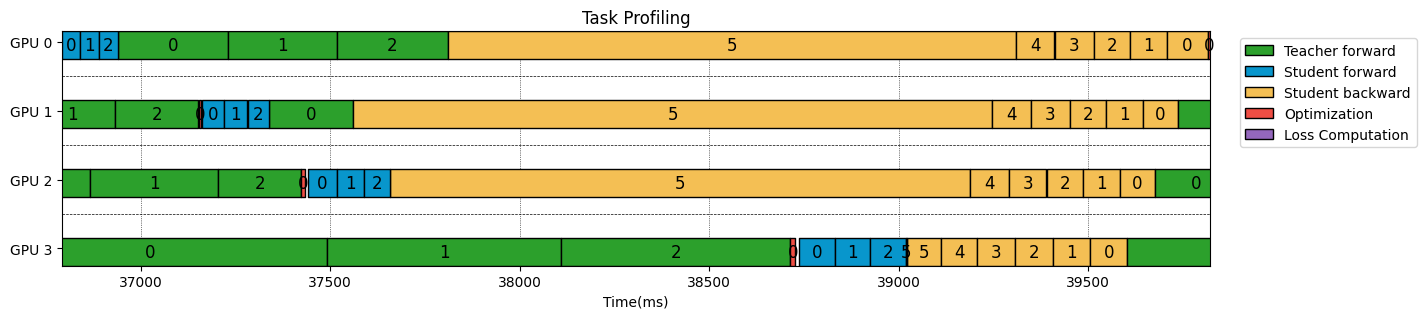

In [22]:
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator

# Ensure data types
filtered_df_8_9['Start'] = filtered_df_8_9['Start'].astype(float)
filtered_df_8_9['End'] = filtered_df_8_9['End'].astype(float)
filtered_df_8_9['gpu'] = filtered_df_8_9['gpu'].astype(int)

fig, ax = plt.subplots(figsize=(12, 3))

gpu_ids = sorted(filtered_df_8_9['gpu'].unique(), reverse=True)
yticks = []
yticklabels = []

show_comm = True
text_labels = []

for idx, gpu_id in enumerate(gpu_ids):
    yticks.append(idx)
    yticklabels.append(f'GPU {gpu_id}')
    gpu_blocks = filtered_df_8_9[filtered_df_8_9['gpu'] == gpu_id]

    for _, row in gpu_blocks.iterrows():
        # 해당 스케줄링 블록이 어떤 역할을 하는지에 따라 색상과 위치를 결정
        is_target = row['target']

        is_forward_target = row['task'] == 'compute_forward' and is_target
        is_forward_online = row['task'] == 'compute_forward' and not is_target
        is_backward = row['task'] == 'compute_backward'
        is_optimize = row['task'] == 'compute_optimize'
        is_comploss = row['task'] == 'compute_loss'
        
        is_comm = row['task'] in ['copy_batch', 'copy_batch_out', 'copy_grad', 'copy_grad_out']
        is_comm_forward_target = row['task'] in ['copy_batch', 'copy_batch_out'] and is_target
        is_comm_forward_online = row['task'] in ['copy_batch', 'copy_batch_out'] and not is_target
        is_comm_backward = is_comm and not is_target
        
        if show_comm:
            if is_comm:
                is_comm_out = row['task'].endswith('_out')
                if is_comm_forward_target:
                    y_pos = idx + 0.10
                if is_comm_forward_online:
                    y_pos = idx + 0.15
                if is_comm_backward:
                    y_pos = idx + 0.20                    
                color = '#bdbdbd' if is_comm_out else '#eaeaea'
                z = 1 if is_comm_out else 0
                z=0
                y_pos += 0.05 if is_comm_out else 0
            else:
                if is_optimize:
                    y_pos = idx + 0.05
                    color = '#EF4E44'  # red
                    z = 3
                if is_forward_target:
                    y_pos = idx - 0.05
                    color = 'tab:green'
                    z = 2
                if is_comploss:
                    y_pos = idx - 0.05
                    color = 'tab:purple'
                    z = 3
                if is_forward_online:
                    y_pos = idx - 0.10
                    color = '#0896CC'  # blue
                    z = 3
                if is_backward:
                    y_pos = idx + 0.00
                    color = '#F4BF54' # yellowish orange
                    z = 2
            y_pos = idx

        ax.broken_barh(
            [(row['Start'], row['Duration'])],
            (y_pos - 0.25, 0.4),  # sub-row height
            facecolors=color,
            edgecolor='black',
            zorder=z
        )
        text_labels.append({
            'x': row['Start'] + row['Duration'] / 2,
            'y': y_pos - 0.05,
            # 'label': str(row['batch']) + row['block_id'][0] + row['block_id'].split("_")[1]
            'label': row['block_id'][-1]
        })

ax.set_xlabel('Time(ms)')
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)
ax.set_title('Task Profiling')

# ax.grid(False)
ax.xaxis.grid(True, which='major', linestyle=':', color='black', linewidth=0.5)
for i in range(1, len(gpu_ids)):
    ax.axhline(i - 0.5, color='black', linestyle='--', linewidth=0.5)
# ax.xaxis.set_major_locator(MultipleLocator(50))

plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
ax.margins(x=0, y=0)
plt.tight_layout(pad=0)

# Define legend elements
legend_elements = [
    mpatches.Patch(facecolor='tab:green', edgecolor='black', label='Teacher forward'),
    mpatches.Patch(facecolor='#0896CC', edgecolor='black', label='Student forward'), # blue
    mpatches.Patch(facecolor='#F4BF54', edgecolor='black', label='Student backward'), # yellowish orange
    mpatches.Patch(facecolor='#EF4E44', edgecolor='black', label='Optimization'), # red
    mpatches.Patch(facecolor='tab:purple', edgecolor='black', label='Loss Computation'),
    # mpatches.Patch(facecolor='#eaeaea', edgecolor='black', label='Communication(in)'),
    # mpatches.Patch(facecolor='#bdbdbd', edgecolor='black', label='Communication(out)'),
    # mpatches.Patch(facecolor='#eaeaea', edgecolor='black', label='Communication(in)\n(Batch-F/B-S/T-Ubatch)'),
    # mpatches.Patch(facecolor='#bdbdbd', edgecolor='black', label='Communication(out)\n(Batch-F/B-S/T-Ubatch)'),
]
ax.legend(handles=legend_elements, loc='upper right')

# Apply crop to x-axis
# crop_start = 6916.765
# crop_end = 10835.767012
crop_start = filtered_df_8_9[
    (filtered_df_8_9['batch'] == 7) &
    (filtered_df_8_9['gpu'] == 0) &
    (filtered_df_8_9['target'] == False) &
    (filtered_df_8_9['ubatch'] == 0) &
    (filtered_df_8_9['task'] == 'compute_forward')
]['Start'].min()
crop_end = filtered_df_8_9[
    (filtered_df_8_9['batch'] == 7) &
    (filtered_df_8_9['gpu'] == 0) &
    (filtered_df_8_9['task'] == 'compute_optimize')
]['End'].max()
print(f'1 Iteration time: {crop_end - crop_start} ms')
ax.set_xlim(left=crop_start, right=crop_end)


for item in text_labels:
    if crop_start <= item['x'] <= crop_end:  # Optional: avoid drawing outside crop
        ax.text(item['x'], item['y'], item['label'], ha='center', va='center', color='black', fontsize=12)

plt.legend(handles=legend_elements, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

11760.7 12468.6


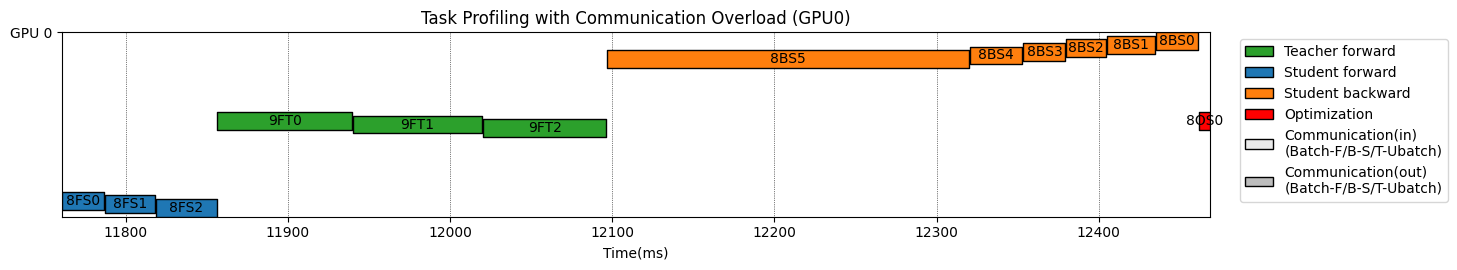

In [26]:
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator

# Ensure data types
filtered_df_8_9['Start'] = filtered_df_8_9['Start'].astype(float)
filtered_df_8_9['End'] = filtered_df_8_9['End'].astype(float)
filtered_df_8_9['gpu'] = filtered_df_8_9['gpu'].astype(int)

SHOW_COMM = True
GPU_ID = 0

fig, ax = plt.subplots(figsize=(12, 2.5))

gpu_ids = sorted(filtered_df_8_9['gpu'].unique(), reverse=True)
yticks = []
yticklabels = []
text_labels = []

for idx, gpu_id in enumerate([GPU_ID]):
    yticks.append(idx)
    yticklabels.append(f'GPU {gpu_id}')
    gpu_blocks = filtered_df_8_9[filtered_df_8_9['gpu'] == gpu_id]

    for _, row in gpu_blocks.iterrows():
        # 해당 스케줄링 블록이 어떤 역할을 하는지에 따라 색상과 위치를 결정
        is_target = row['target']

        is_forward_target = row['task'] == 'compute_forward' and is_target
        is_forward_online = row['task'] == 'compute_forward' and not is_target
        is_backward = row['task'] == 'compute_backward'
        is_optimize = row['task'] == 'compute_optimize'
        is_comploss = row['task'] == 'compute_loss'
        
        is_comm = row['task'] in ['copy_batch', 'copy_batch_out', 'copy_grad', 'copy_grad_out']
        is_comm_forward_target = row['task'] in ['copy_batch', 'copy_batch_out'] and is_target
        is_comm_forward_online = row['task'] in ['copy_batch', 'copy_batch_out'] and not is_target
        is_comm_backward = is_comm and not is_target
        
        if SHOW_COMM:
            if is_comm:
                is_comm_out = row['task'].endswith('_out')
                if is_comm_forward_target:
                    y_pos = idx + 0.1
                elif is_comm_forward_online:
                    y_pos = idx - 0.35
                elif is_comm_backward:
                    y_pos = idx + 0.55
                color = '#bdbdbd' if is_comm_out else '#eaeaea'
                # z = 1 if is_comm_out else 0
                # z=0
                y_pos -= 0.2 if is_comm_out else 0
                offset = int(row['block_id'][-1]) * .02
                y_pos -= offset
            else:
                if is_optimize:
                    y_pos = idx + 0.0
                    color = 'red'
                    z = 3
                if is_forward_target:
                    y_pos = idx - 0
                    color = 'tab:green'
                    z = 2
                if is_comploss:
                    y_pos = idx - 0.45
                    color = 'tab:purple'
                    z = 3
                if is_forward_online:
                    y_pos = idx - 0.45
                    color = 'tab:blue'
                    z = 3
                if is_backward:
                    # y_pos = idx + 0.00
                    y_pos = idx + 0.45
                    color = 'tab:orange'
                    z = 2
                offset = int(row['block_id'][-1]) * .02
                y_pos -= offset

        ax.broken_barh(
            [(row['Start'], row['Duration'])],
            (y_pos - 0.55, 0.1),  # sub-row height (y_pos - 0.09, 0.18), 
            facecolors=color,
            edgecolor='black',
            zorder=z
        )
        text_labels.append({
        	'x': row['Start'] + row['Duration'] / 2,
        	'y': y_pos - 0.5,
        	'label': str(row['batch']) + row['block_id'][0] + row['block_id'].split("_")[1]
    	})

ax.set_xlabel('Time(ms)')
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)
ax.set_title(f'Task Profiling with Communication Overload (GPU{GPU_ID})')

ax.grid(False)
ax.xaxis.grid(True, which='major', linestyle=':', color='black', linewidth=0.5)
# for i in range(1, 4):
#     ax.axhline(i, color='black', linestyle='--', linewidth=0.5)
# ax.xaxis.set_major_locator(MultipleLocator(50))

plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
ax.margins(x=0, y=0)
plt.tight_layout(pad=0)

# Define legend elements
legend_elements = [
    mpatches.Patch(facecolor='tab:green', edgecolor='black', label='Teacher forward'),
    mpatches.Patch(facecolor='tab:blue', edgecolor='black', label='Student forward'),
    mpatches.Patch(facecolor='tab:orange', edgecolor='black', label='Student backward'),
    mpatches.Patch(facecolor='red', edgecolor='black', label='Optimization'),
    # mpatches.Patch(facecolor='tab:purple', edgecolor='black', label='Loss Computation'),
    # mpatches.Patch(facecolor='#eaeaea', edgecolor='black', label='Communication(in)'),
    # mpatches.Patch(facecolor='#bdbdbd', edgecolor='black', label='Communication(out)'),
    mpatches.Patch(facecolor='#eaeaea', edgecolor='black', label='Communication(in)\n(Batch-F/B-S/T-Ubatch)'),
    mpatches.Patch(facecolor='#bdbdbd', edgecolor='black', label='Communication(out)\n(Batch-F/B-S/T-Ubatch)'),
]
ax.legend(handles=legend_elements, loc='upper right')

# Apply crop to x-axis
crop_start = 6916.765
crop_end = 10835.767012
crop_start = filtered_df_8_9[
    (filtered_df_8_9['batch'] == 8) &
    (filtered_df_8_9['gpu'] == 0) &
    (filtered_df_8_9['target'] == False) &
    (filtered_df_8_9['ubatch'] == 0) &
    (filtered_df_8_9['task'] == 'compute_forward')
]['Start'].min()
crop_end = filtered_df_8_9[
    (filtered_df_8_9['batch'] == 8) &
    (filtered_df_8_9['gpu'] == 0) &
    (filtered_df_8_9['task'] == 'compute_optimize')
]['End'].max()
print(crop_start, crop_end)
ax.set_xlim(left=crop_start, right=crop_end)


for item in text_labels:
    if crop_start <= item['x'] <= crop_end:  # Optional: avoid drawing outside crop
        ax.text(item['x'], item['y'], item['label'], ha='center', va='center', color='black', fontsize=10)

plt.legend(handles=legend_elements, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

### NVTX Visualization with csv

In [27]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator
import numpy as np

def assign_color(row):
    task = row['task'].lower()
    is_teacher = row['target'] is True
    is_student = row['target'] is False

    # Teacher forward
    if is_teacher:
        if 'compute_forward' in task:
            return '#01b112'  # 진한 초록
        elif 'copy_model' in task:
            return '#74cb15'  # 밝은 청록
        elif 'copy_batch' in task:
            return '#b8e428'  # 연한 초록
        elif 'copy_batch_out' in task:
            return '#f9fc45'  # 아주 연한 녹색

    # Student forward
    if is_student:
        if 'compute_forward' in task:
            return '#0265ac'  # 진한 파랑
        elif 'copy_model' in task:
            return '#008ab5'  # 연한 청록
        elif 'copy_batch' in task:
            return '#00acb7'  # 중간 파랑
        elif 'copy_batch_out' in task:
            return '#00d2a6'  # 연한 파랑

    # Student backward
    if is_student:
        if 'compute_backward' in task:
            return '#cf5702'  # 진한 오렌지
        elif 'compute_loss' in task:
            return '#ee8925'  # 덜진한 오렌지
        elif 'copy_grad' in task:
            return '#e99b1e'  # 중간 오렌지
        elif 'copy_grad_out' in task:
            return '#dbbd24'  # 밝은 오렌지

    # Optimization
    if 'compute_optimize' in task:
        return '#d62728'  # 빨강

    # Feed / terminate
    if 'feed_batch' in task or 'terminate' in task:
        return '#7f7f7f'  # 회색

    # Default fallback
    return '#bdbdbd'  # 흐린 회색

import matplotlib.patches as mpatches

legend_elements = [
    # Teacher Forward 관련
    mpatches.Patch(facecolor='#01b112', label='Teacher Compute Forward'),     # 진한 초록
    mpatches.Patch(facecolor='#74cb15', label='Teacher Copy Model'),          # 중간 초록
    mpatches.Patch(facecolor='#b8e428', label='Teacher Copy Batch'),          # 연한 초록
    mpatches.Patch(facecolor='#f9fc45', label='Teacher Copy Batch Out'),      # 아주 연한 초록

    # Student Forward 관련
    mpatches.Patch(facecolor='#0265ac', label='Student Compute Forward'),     # 진한 파랑
    mpatches.Patch(facecolor='#008ab5', label='Student Copy Model'),          # 중간 파랑
    mpatches.Patch(facecolor='#00acb7', label='Student Copy Batch'),          # 연한 파랑
    mpatches.Patch(facecolor='#00d2a6', label='Student Copy Batch Out'),      # 아주 연한 파랑

    # Student Backward 관련
    mpatches.Patch(facecolor='#cf5702', label='Student Compute Backward'),    # 진한 오렌지
    mpatches.Patch(facecolor='#de7e0e', label='Compute Loss'),                # 중간 오렌지
    mpatches.Patch(facecolor='#e99b1e', label='Copy Grad'),                   # 밝은 오렌지
    mpatches.Patch(facecolor='#dbbd24', label='Copy Grad Out'),              # 아주 밝은 오렌지

    # 기타
    mpatches.Patch(facecolor='#d62728', label='Optimization'),               # 빨강
    mpatches.Patch(facecolor='#7f7f7f', label='Feed/Terminate'),             # 회색
]


kd_task_order = [
    "feed_batch",
    "copy_model",
    "copy_batch",
    "compute_forward",
    "copy_batch_out",
    "compute_loss",
    "compute_backward",
    "copy_grad_out",
    "copy_grad",
    "compute_optimize",
    "terminate"
]


BATCH_SIZE = 128

#df_merged['Start'] = df_merged['Duration'].cumsum().shift(fill_value=0)
df_merged['Start'] = df_merged.groupby('gpu')['Duration'].cumsum().shift(fill_value=0)
df_merged['End'] = df_merged['Start'] + df_merged['Duration']

# teacher와 student를 시각적으로 분리 (겹치지 않도록)
def offset_id(row):
    return row['gpu'] + (0.2 if row['target'] else -0.2)

df_merged['color'] = df_merged.apply(assign_color, axis=1)
df_merged['y_pos'] = df_merged.apply(lambda row: row['gpu'] + (0.2 if row['target'] else -0.2), axis=1)

# Gantt-style plot
fig, ax = plt.subplots(figsize=(18, 6))
unique_gpus = sorted(df_merged['gpu'].unique())
y_margin = 0.6  # margin around center y for colored bands


for i, gpu in enumerate(unique_gpus):
    color = '#f0f0f0' if i % 2 == 0 else '#e0e0e0'
    plt.axhspan(gpu - y_margin, gpu + y_margin, color=color, alpha=0.5, zorder=0)


for _, row in df_merged.iterrows():
    plt.barh(
        y=row['y_pos'],
        width=row['Duration'],
        left=row['Start'],
        height=0.35,
        color=row['color'],
        edgecolor=row['color'],      # 내부 색상과 동일한 윤곽선
        linewidth=0.2,
        alpha=0.95
    )

plt.xticks(fontsize=13)
plt.yticks(unique_gpus, fontsize=13)
plt.xlabel('Cumulative Duration (ms)', fontsize=14)
plt.ylabel('GPU ID', fontsize=14)
plt.title(f'Even Partitioning GPU Task Durationline (Batch Size: {BATCH_SIZE}, Iteration 6-10)', fontsize=16, pad=20)
plt.grid(axis='x', linestyle='-', linewidth=0.5)

ax.xaxis.set_major_locator(MultipleLocator(2000))  # 1000ms 단위 눈금선
plt.legend(
    handles=legend_elements,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
    frameon=True
)


plt.tight_layout()
plt.show()

NameError: name 'df_merged' is not defined

In [10]:
df_8_mem = df_merged[(df_merged['batch'] == 8) & (df_merged['gpu'] != -1)].reset_index(drop=True)

heatmap_data = df_8_mem.pivot_table(
    index='gpu',
    columns='task',
    values='mem',
    aggfunc='mean' # mean or max
)
ordered_columns = [col for col in kd_task_order if col in heatmap_data.columns]
heatmap_data = heatmap_data[ordered_columns]
heatmap_data = heatmap_data.sort_index(ascending=False)

plt.figure(figsize=(18, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap='YlOrRd',
    linewidths=0.5,
    # vmax=5000,
    annot_kws={"size": 14},  # 히트맵 내부 숫자 크기
    cbar_kws={'label': 'Average Memory (MB)', 'shrink': 0.8}
)

# x축, y축, 제목 폰트 크기 조정
plt.xticks(rotation=30, ha='right', fontsize=13)
plt.yticks(fontsize=13)
plt.title(f'Even Partitioning Average Memory Usage (Batch size: {BATCH_SIZE}, Iteration: 8)', fontsize=16, pad=20)
plt.xlabel('Task', fontsize=14)
plt.ylabel('GPU ID', fontsize=14)
plt.tight_layout()
plt.show()

KeyError: 'mem'

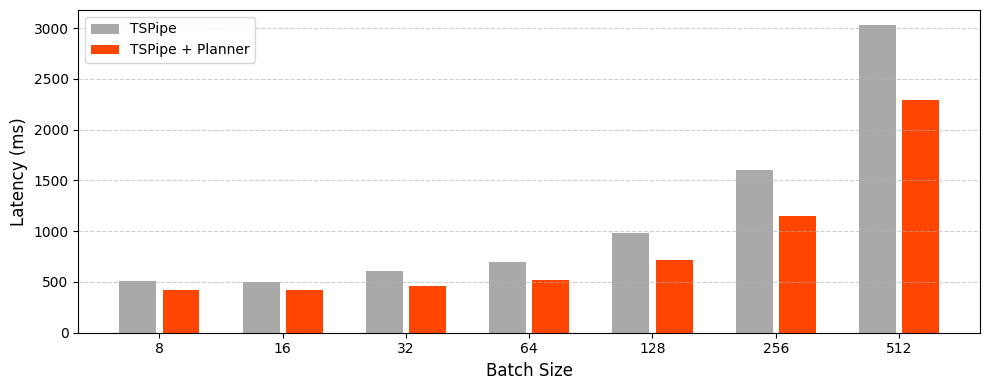

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Data
batch_sizes = [8, 16, 32, 64, 128, 256, 512]
baseline_latency = [513.00, 501.92, 603.93, 696.41, 978.20, 1605.90, 3027.90]
planner_latency = [416.79, 416.30, 456.42, 521.21, 714.50, 1149.00, 2290.40]

# Bar width and positions

# Adjust bar width and spacing between bar pairs
bar_width = 0.3
spacing = 0.05
index = np.arange(len(batch_sizes))

# Custom colors
baseline_color = '#FFB000'   # Blue
planner_color = '#EF4E44'    # Orange

# Plotting
plt.figure(figsize=(10, 4))
plt.bar(index - (bar_width + spacing) / 2, baseline_latency, bar_width, label='TSPipe', color='darkgrey')
plt.bar(index + (bar_width + spacing) / 2, planner_latency, bar_width, label='TSPipe + Planner', color='orangered')

# Labels and formatting
plt.xlabel('Batch Size', fontsize=12)
plt.ylabel('Latency (ms)', fontsize=12)
# plt.title('Per-Iteration Latency Comparison')
plt.xticks(index, batch_sizes)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


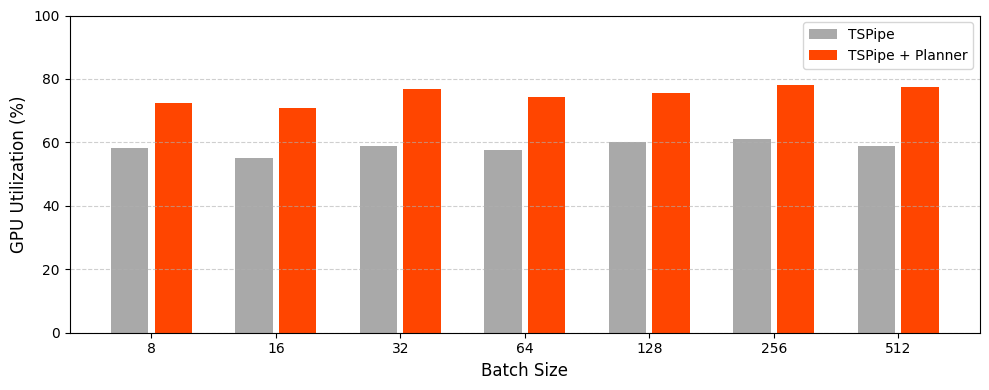

In [3]:
# Utilization data
baseline_util = [58.38, 54.94, 58.72, 57.59, 60.05, 61.21, 58.75]
planner_util = [72.53, 70.79, 76.88, 74.18, 75.72, 78.06, 77.44]

# Plotting
plt.figure(figsize=(10, 4))
plt.bar(index - (bar_width + spacing) / 2, baseline_util, bar_width, label='TSPipe', color='darkgrey')
plt.bar(index + (bar_width + spacing) / 2, planner_util, bar_width, label='TSPipe + Planner', color='orangered')

# Labels and formatting
plt.xlabel('Batch Size', fontsize=12)
plt.ylabel('GPU Utilization (%)', fontsize=12)
# plt.title('GPU Utilization Comparison')
plt.xticks(index, batch_sizes)
plt.ylim(0, 100)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


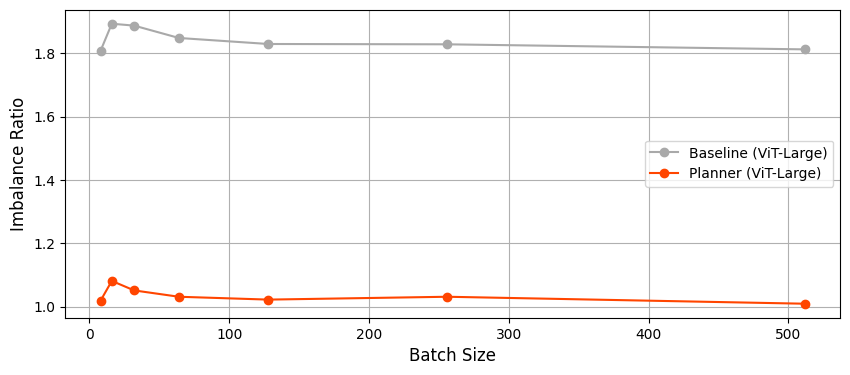

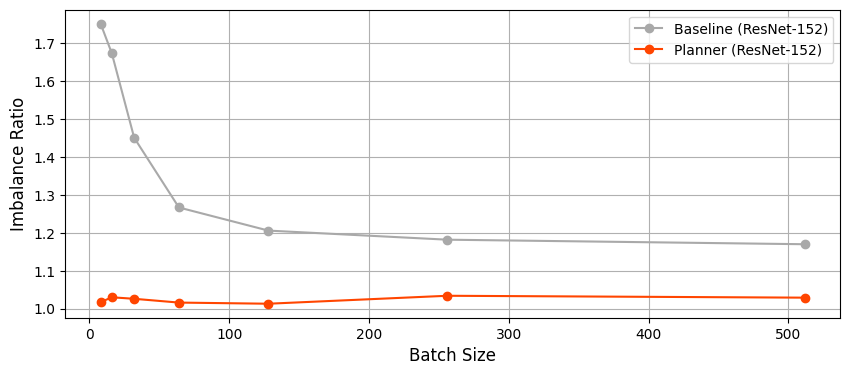

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Batch sizes
batch_sizes = [8, 16, 32, 64, 128, 256, 512]

# Imbalance ratios
vit_baseline = [1.808, 1.893, 1.887, 1.848, 1.829, 1.828, 1.812]
vit_ourwork = [1.019, 1.081, 1.051, 1.031, 1.022, 1.031, 1.009]

resnet_baseline = [1.752, 1.674, 1.451, 1.267, 1.206, 1.182, 1.170]
resnet_ourwork = [1.017, 1.030, 1.026, 1.016, 1.013, 1.034, 1.029]

# Compute improvements
vit_improvement = [(b - o) / b * 100 for b, o in zip(vit_baseline, vit_ourwork)]
resnet_improvement = [(b - o) / b * 100 for b, o in zip(resnet_baseline, resnet_ourwork)]

# Create DataFrame for user
df = pd.DataFrame({
    'Batch Size': batch_sizes * 2,
    'Model': ['ViT-Large'] * 7 + ['ResNet-152'] * 7,
    'Imbalance Ratio (Baseline)': vit_baseline + resnet_baseline,
    'Imbalance Ratio (Planner)': vit_ourwork + resnet_ourwork,
    'Improvement (%)': vit_improvement + resnet_improvement
})

# Plot for ViT-Large
plt.figure(figsize=(10, 4))
plt.plot(batch_sizes, vit_baseline, marker='o', label='Baseline (ViT-Large)', color='darkgrey')
plt.plot(batch_sizes, vit_ourwork, marker='o', label='Planner (ViT-Large)', color='orangered')
plt.xlabel("Batch Size", fontsize=12)
plt.ylabel("Imbalance Ratio", fontsize=12)
# plt.title('Imbalance Ratio vs Batch Size (ViT-Large)')
plt.legend()
plt.grid(True)
plt.show()

# Plot for ResNet-152
plt.figure(figsize=(10, 4))
plt.plot(batch_sizes, resnet_baseline, marker='o', label='Baseline (ResNet-152)', color='darkgrey')
plt.plot(batch_sizes, resnet_ourwork, marker='o', label='Planner (ResNet-152)', color='orangered')
plt.xlabel("Batch Size", fontsize=12)
plt.ylabel("Imbalance Ratio", fontsize=12)
# plt.title('Imbalance Ratio vs Batch Size (ResNet-152)')
plt.legend()
plt.grid(True)
plt.show()

### Per-stage time

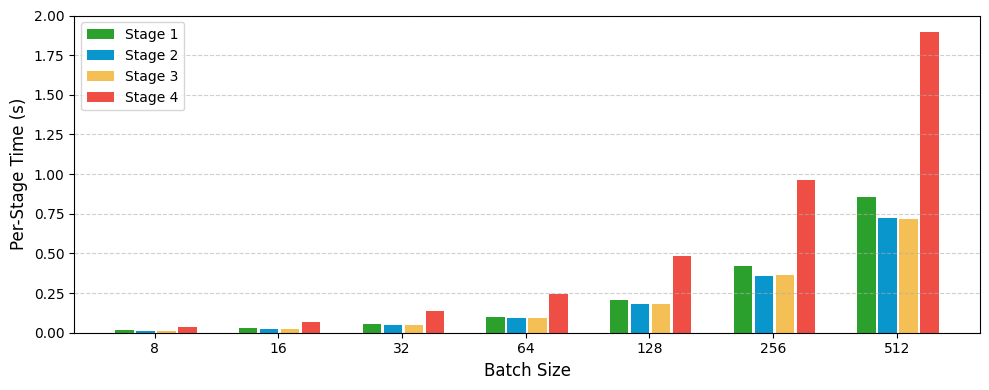

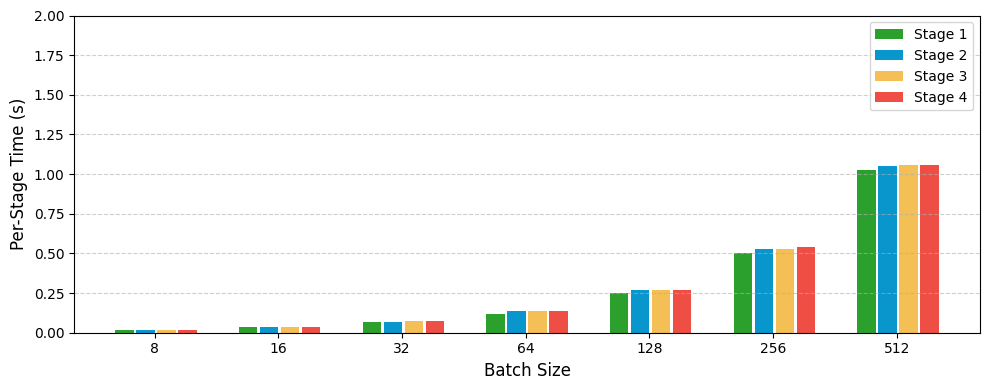

In [13]:
# Re-import needed libraries after state reset
import matplotlib.pyplot as plt
import numpy as np

# Batch sizes and per-stage times (ViT-Large model only)
batch_sizes = [8, 16, 32, 64, 128, 256, 512]

# Baseline stage times for ViT-Large
baseline_stage_times = [
    [0.017, 0.013, 0.013, 0.035],
    [0.028, 0.024, 0.023, 0.068],
    [0.056, 0.047, 0.049, 0.135],
    [0.099, 0.091, 0.092, 0.242],
    [0.207, 0.184, 0.183, 0.483],
    [0.421, 0.360, 0.361, 0.961],
    [0.854, 0.721, 0.717, 1.897]
]

# Ours stage times for ViT-Large
ours_stage_times = [
    [0.020, 0.019, 0.019, 0.020],
    [0.034, 0.035, 0.036, 0.039],
    [0.066, 0.070, 0.075, 0.075],
    [0.120, 0.134, 0.134, 0.135],
    [0.250, 0.269, 0.268, 0.270],
    [0.505, 0.529, 0.527, 0.542],
    [1.023, 1.053, 1.056, 1.057]
]

stage_labels = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']
x = np.arange(len(batch_sizes))
colors = ['tab:green', '#0896CC', '#F4BF54', '#EF4E44']
bar_width = 0.15
spacing = 0.02

def plot_grouped_bar_with_formatting(data):
    fig, ax = plt.subplots(figsize=(10, 4))
    for i in range(4):
        offset = i * (bar_width + spacing)
        stage_times = [data[j][i] for j in range(len(batch_sizes))]
        ax.bar(x + offset, stage_times, width=bar_width, color=colors[i], label=stage_labels[i])
    total_width = 4 * (bar_width + spacing) - spacing
    ax.set_xlabel('Batch Size', fontsize=12)
    ax.set_ylabel('Per-Stage Time (s)', fontsize=12)

    ax.set_xticks(x + total_width / 2 - (bar_width + spacing) / 2)
    ax.set_xticklabels(batch_sizes)
    ax.set_ylim(0, 2.0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))
    ax.legend()
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    return fig

fig1 = plot_grouped_bar_with_formatting(baseline_stage_times)
fig2 = plot_grouped_bar_with_formatting(ours_stage_times)

plt.show()

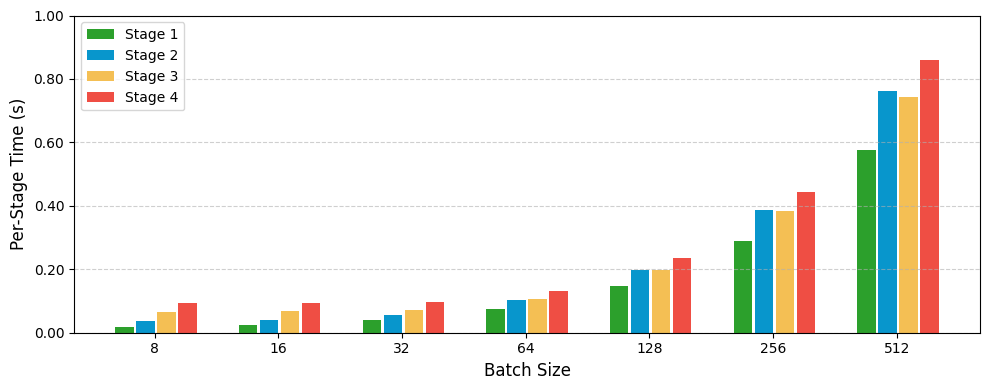

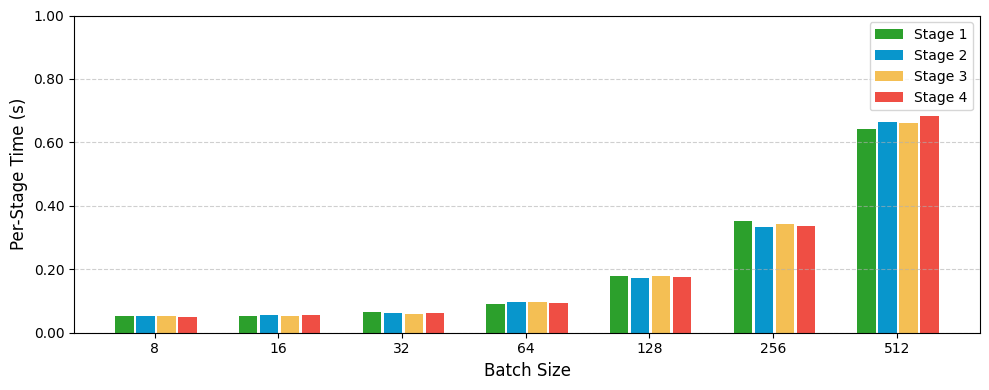

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Batch sizes and per-stage times (ResNet-152 model only)
batch_sizes = [8, 16, 32, 64, 128, 256, 512]

# Baseline stage times for ResNet-152
baseline_stage_times_resnet = [
    [0.018, 0.037, 0.066, 0.095],
    [0.024, 0.041, 0.067, 0.095],
    [0.039, 0.057, 0.073, 0.097],
    [0.075, 0.103, 0.107, 0.132],
    [0.146, 0.198, 0.199, 0.235],
    [0.290, 0.387, 0.384, 0.445],
    [0.575, 0.761, 0.743, 0.859]
]

# Ours stage times for ResNet-152
ours_stage_times_resnet = [
    [0.054, 0.053, 0.053, 0.051],
    [0.053, 0.056, 0.054, 0.056],
    [0.064, 0.063, 0.060, 0.062],
    [0.092, 0.097, 0.096, 0.095],
    [0.179, 0.173, 0.178, 0.177],
    [0.352, 0.333, 0.342, 0.335],
    [0.642, 0.665, 0.661, 0.682]
]

stage_labels = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']
x = np.arange(len(batch_sizes))
colors = ['tab:green', '#0896CC', '#F4BF54', '#EF4E44']
bar_width = 0.15
spacing = 0.02

# Function reused for plotting
def plot_grouped_bar_with_formatting(data):
    fig, ax = plt.subplots(figsize=(10, 4))
    for i in range(4):
        offset = i * (bar_width + spacing)
        stage_times = [data[j][i] for j in range(len(batch_sizes))]
        ax.bar(x + offset, stage_times, width=bar_width, color=colors[i], label=stage_labels[i])
    total_width = 4 * (bar_width + spacing) - spacing
    ax.set_xlabel('Batch Size', fontsize=12)
    ax.set_ylabel('Per-Stage Time (s)', fontsize=12)
    ax.set_xticks(x + total_width / 2 - (bar_width + spacing) / 2)
    ax.set_xticklabels(batch_sizes)
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))
    ax.legend()
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    return fig

fig3 = plot_grouped_bar_with_formatting(baseline_stage_times_resnet)
fig4 = plot_grouped_bar_with_formatting(ours_stage_times_resnet)

plt.show()
